In [1]:
import tensorflow as tf

model = tf.keras.models.load_model("models/stage2_non_dino_species.keras")
print("Model loaded!")

Model loaded!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

def show_with_prediction(img_path):
    img = Image.open(img_path)

    img_model = img.resize((224, 224))
    x = image.img_to_array(img_model)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)
    decoded = decode_predictions(preds, top=3)[0]

    plt.imshow(img)
    plt.axis("off")

    title = "\n".join([f"{label}: {prob:.2f}" for _, label, prob in decoded])
    plt.title(title)

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


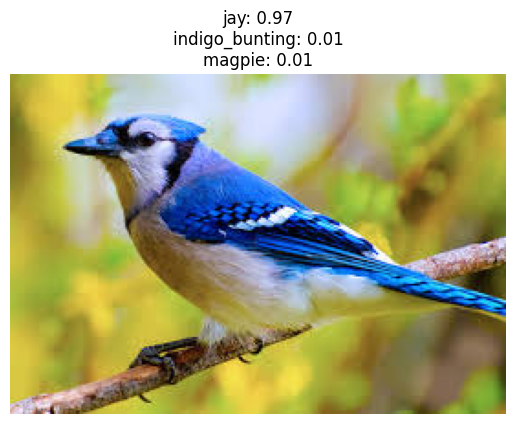

In [8]:
img_path = "dataset/test_images/bird.jpeg"

results = show_with_prediction(img_path)